###**INFERENTIAL STATISTICS**

In [ ]:
# importing the libraries to help the reading and manipulating the data set
import numpy as np
import pandas as pd

# Libraries to help data visualization of dataset
import matplotlib.pyplot as plt
import seaborn as sns
# Importing the statistics liberary to do statics calculation
import scipy.stats as stats
from scipy.stats import norm
from scipy.stats import binom

from statsmodels.formula.api import ols
import statsmodels.api as sm

from scipy.stats import shapiro, levene, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd


# We are ristricting the float value upto 3 decimal places
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Problem 1

A physiotherapist with a male football team is interested in studying the relationship between foot injuries and the positions at which the players play from the data collected.

|                     | Striker | Forward | Attacking Midfielder | Winger | Total |
|---------------------|---------|---------|----------------------|--------|-------|
|
**Players Injured** |      45  |      56   |                   24 |     20 |   **145** |
|
**Players Not Injured** |   32 |      38 |                   11 |      9 |    **90** |
|
**Total**           |      **77** |      **94** |                   **35** |     **29** |   **235** |


**Based on the above data, answer the following questions.**

1.1 What is the probability that a randomly chosen player would suffer an injury?

1.2 What is the probability that a player is a forward or a winger?

1.3 What is the probability that a randomly chosen player plays in a striker position and has a foot injury?

1.4 What is the probability that a randomly chosen injured player is a striker?

In [ ]:
# Create a DataFrame
data = {
    'Position': ['Players Injured', 'Players Not Injured', 'Total'],
    'Striker': [45, 32, 77],
    'Forward': [56, 38, 94],
    'Attacking Midfielder': [24, 11, 35],
    'Winger': [20, 9, 29],
    'Total': [145, 90, 235]
}
df = pd.DataFrame(data)
# Display the DataFrame
df

,Position,Striker,Forward,Attacking Midfielder,Winger,Total
0,Players Injured,45,56,24,20,145
1,Players Not Injured,32,38,11,9,90
2,Total,77,94,35,29,235


In [ ]:
# Calculate total players
total_players = df.loc[df['Position'] == 'Total', 'Total'].values[0]
print("The total players are : ",total_players)


The total players are :  235


* Firstly I ll be calculating the Total players are : 235

**1.1 What is the probability that a randomly chosen player would suffer an injury?**


In [ ]:
# To find the probability, first we need to find the total number of injured players and the total number of players
total_injured_players = df.loc[df['Position'] == 'Players Injured', 'Total'].values[0]
prob_injury = total_injured_players / total_players
print(f" The Probability that a randomly chosen player would suffer an injury : {prob_injury:.3f}")


 The Probability that a randomly chosen player would suffer an injury : 0.617


* So the Probability that a randomaly choosen player who suffer an injury is approximately 0.617 or 61.7%


**1.2 What is the probability that a player is a forward or a winger?**

In [ ]:
# To find this probability, we need to divide the total number of forwards and wingers by the total number of players.
total_forwards = df.loc[df['Position'] == 'Total', 'Forward'].values[0]
total_wingers = df.loc[df['Position'] == 'Total', 'Winger'].values[0]
prob_forward_or_winger = (total_forwards + total_wingers) / total_players
print(f" Probability that a player is a forward or a winger: {prob_forward_or_winger:.3f}")


 Probability that a player is a forward or a winger: 0.523


* So, the probability that a player is a forward or a winger is approximately 0.523 or 52.3%.

**1.3 What is the probability that a randomly chosen player plays in a striker position and has a foot injury?**

In [ ]:
# o find this probability, we divide the number of injured strikers by the total number of players.
injured_strikers = df.loc[df['Position'] == 'Players Injured', 'Striker'].values[0]
prob_striker_injury = injured_strikers / total_players
print(f"Probability that a randomly chosen player plays in a striker position and has a foot injury: {prob_striker_injury:.3f}")

Probability that a randomly chosen player plays in a striker position and has a foot injury: 0.191


* So, the probability that a randomly chosen player plays in a striker position and has a foot injury is approximately 0.191 or 19.1%.

**1.4 What is the probability that a randomly chosen injured player is a striker?**

In [ ]:
# To find this probability, we divide the number of injured strikers by the total number of injured players.
prob_injured_striker = injured_strikers / total_injured_players
print(f" The probability that a randomly chosen injured player is a striker: {prob_injured_striker:.3f}")


 The probability that a randomly chosen injured player is a striker: 0.310


* So, the probability that a randomly chosen injured player is a striker is approximately 0.310 or 31.0%.

# Problem 2
The breaking strength of gunny bags used for packaging cement is normally distributed with a mean of 5 kg per sq. centimeter and a standard deviation of 1.5 kg per sq. centimeter. The quality team of the cement company wants to know the following about the packaging material to better understand wastage or pilferage within the supply chain; Answer the questions below based on the given information; (Provide an appropriate visual representation of your answers, without which marks will be deducted)

2.1 What proportion of the gunny bags have a breaking strength of less than 3.17 kg per sq cm?

2.2 What proportion of the gunny bags have a breaking strength of at least 3.6 kg per sq cm.?

2.3 What proportion of the gunny bags have a breaking strength between 5 and 5.5 kg per sq cm.?

2.4 What proportion of the gunny bags have a breaking strength NOT between 3 and 7.5 kg per sq cm.?

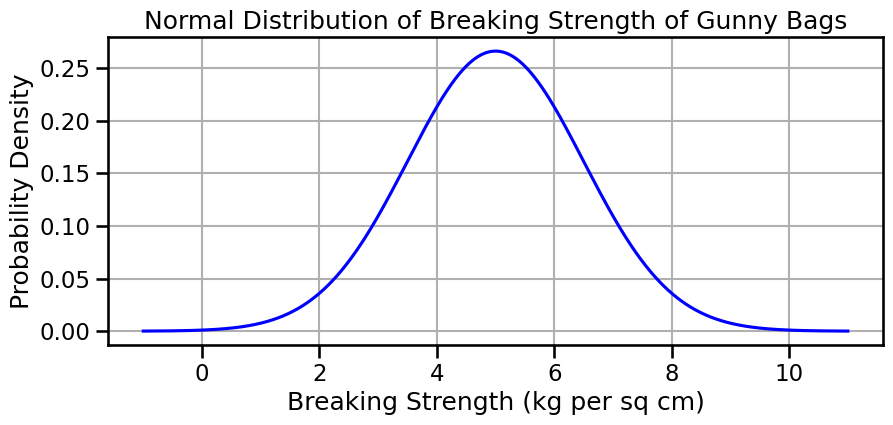

In [ ]:
sns.set_context("talk")
# Given parameters
mean_strength = 5  # mean breaking strength
std_dev_strength = 1.5  # standard deviation of breaking strength

# Define a range for the x-axis
x = np.linspace(mean_strength - 4*std_dev_strength, mean_strength + 4*std_dev_strength, 1000)
y = norm.pdf(x, mean_strength, std_dev_strength)

# Plot the normal distribution
plt.figure(figsize=(10, 4))
sns.lineplot(x=x, y=y, color='blue')
plt.title('Normal Distribution of Breaking Strength of Gunny Bags')
plt.xlabel('Breaking Strength (kg per sq cm)')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()


**2.1 What proportion of the gunny bags have a breaking strength of less than 3.17 kg per sq cm?**

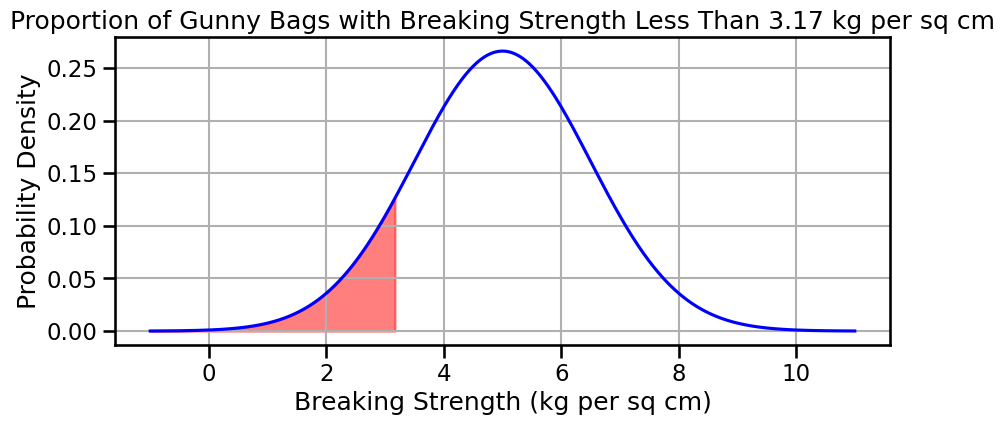

Proportion of gunny bags with breaking strength less than 3.17 kg per sq cm: 0.1112


In [ ]:
# Calculate the proportion
strength_less_3_17 = norm.cdf(3.17, mean_strength, std_dev_strength)

# Plot the visual representation
plt.figure(figsize=(10, 4))
sns.lineplot(x=x, y=y, color='blue')
plt.fill_between(x, y, where=(x <= 3.17), color='red', alpha=0.5)
plt.title('Proportion of Gunny Bags with Breaking Strength Less Than 3.17 kg per sq cm')
plt.xlabel('Breaking Strength (kg per sq cm)')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

print(f"Proportion of gunny bags with breaking strength less than 3.17 kg per sq cm: {strength_less_3_17:.4f}")


* With the help of Cumulative distribution Function (CDF), we had find the breaking strength which is less than 3.17 kg per sq cm.

* After analysing from graphically, we have found out the probability or area on the left side of red line are less than 3.17 kg per sq. cm. The cumulative Distribution on left side of line is 0.1112. Hence, the probability is 11.12%.

* Proportion of gunny bags with breaking strength less than 3.17 kg per sq. cm are approximately 0.1112 or 11.12%.


**2.2 What proportion of the gunny bags have a breaking strength at least 3.6 kg per sq cm.?**

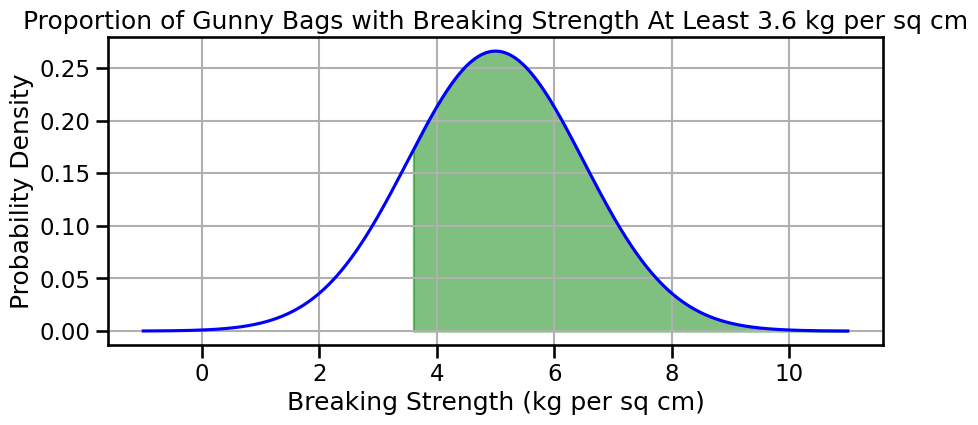

Proportion of gunny bags with breaking strength at least 3.6 kg per sq cm: 0.8247


In [ ]:
# Calculate the proportion
strength_atleast_3_6 = 1 - norm.cdf(3.6, mean_strength, std_dev_strength)

# Plot the visual representation
plt.figure(figsize=(10, 4))
sns.lineplot(x=x, y=y, color='blue')
plt.fill_between(x, y, where=(x >= 3.6), color='green', alpha=0.5)
plt.title('Proportion of Gunny Bags with Breaking Strength At Least 3.6 kg per sq cm')
plt.xlabel('Breaking Strength (kg per sq cm)')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

print(f"Proportion of gunny bags with breaking strength at least 3.6 kg per sq cm: {strength_atleast_3_6:.4f}")


* We are using Cumulative Distribution Function (CDF) for finding the breaking strength at least 3.6 kg per sq. cm.

* After analysing the graph for the above question, we got the probability or area on the right side of the green line that the proportion is at least 3.6 kg per sq cm.

* The Cumulative Distribution area under the Red Region is 0.8247. So, the cumulative probability is 82.47%


**2.3 What proportion of the gunny bags have a breaking strength between 5 and 5.5 kg per sq cm.?**

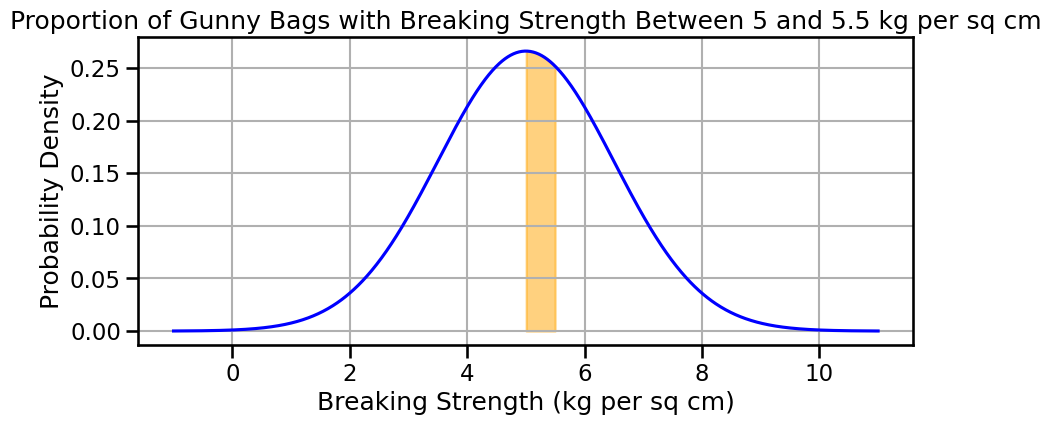

Proportion of gunny bags with breaking strength between 5 and 5.5 kg per sq cm: 0.1306


In [ ]:
# Calculate the proportion
strength_between = norm.cdf(5.5, mean_strength, std_dev_strength) - norm.cdf(5, mean_strength, std_dev_strength)

# Plot the visual representation
plt.figure(figsize=(10, 4))
sns.lineplot(x=x, y=y, color='blue')
plt.fill_between(x, y, where=((x >= 5) & (x <= 5.5)), color='orange', alpha=0.5)
plt.title('Proportion of Gunny Bags with Breaking Strength Between 5 and 5.5 kg per sq cm')
plt.xlabel('Breaking Strength (kg per sq cm)')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

print(f"Proportion of gunny bags with breaking strength between 5 and 5.5 kg per sq cm: {strength_between:.4f}")


* We are using Cumulative Distribution Function (CDF) for finding the breaking strength between 5 and 5.5 kg per sq. cm

* We need to find out the probability or area under the coloured lines for the given question that proportion between 5 and 5.5 kg per sq. cm.

* We can see that the cumulative probability is 13.1% which is low because the interval between 5 and 5.5 kg per sq. cm is very less.


**2.4 What proportion of the gunny bags have a breaking strength NOT between 3 and 7.5 kg per sq cm.?**

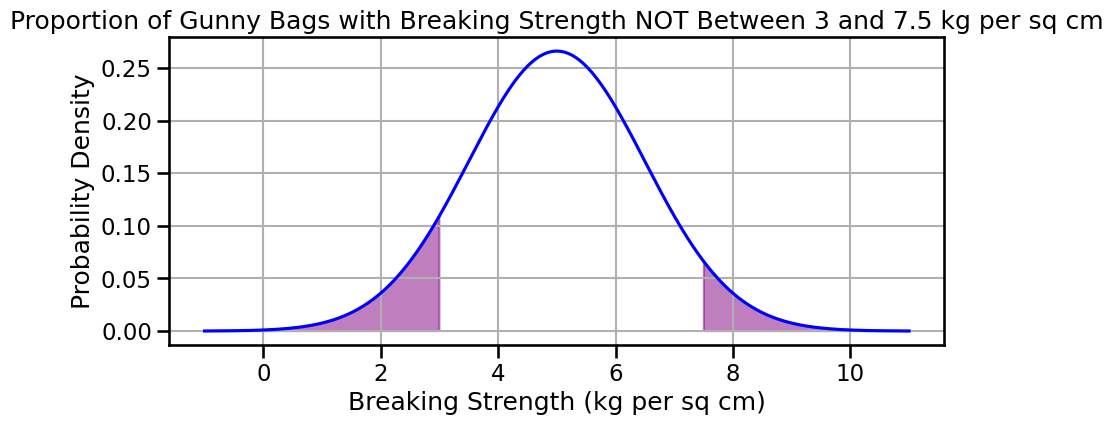

Proportion of gunny bags with breaking strength NOT between 3 and 7.5 kg per sq cm: 0.1390


In [ ]:
# Calculate the proportion
strength_not = norm.cdf(3, mean_strength, std_dev_strength) + (1 - norm.cdf(7.5, mean_strength, std_dev_strength))
# Plot the visual representation
plt.figure(figsize=(10, 4))
sns.lineplot(x=x, y=y, color='blue')
plt.fill_between(x, y, where=(x <= 3) | (x >= 7.5), color='purple', alpha=0.5)
plt.title('Proportion of Gunny Bags with Breaking Strength NOT Between 3 and 7.5 kg per sq cm')
plt.xlabel('Breaking Strength (kg per sq cm)')
plt.ylabel('Probability Density')
plt.grid(True)
plt.show()

print(f"Proportion of gunny bags with breaking strength NOT between 3 and 7.5 kg per sq cm: {strength_not:.4f}")


* We are using Cumulative Distribution Function (CDF) for finding the breaking strength NOT between 3 and 7.5 kg per sq cm

* From the above plot, we need to find out the probability or area under the purple-coloured lines for the given question that the proportion is NOT between 3 and 7.5 kg per sq. cm.

* We can see that the cumulative probability is 13.9%


# Problem 3
Zingaro stone printing is a company that specializes in printing images or patterns on polished or unpolished stones. However, for the optimum level of printing of the image, the stone surface has to have a Brinell's hardness index of at least 150. Recently, Zingaro has received a batch of polished and unpolished stones from its clients. Use the data provided to answer the following (assuming a 5% significance level);

3.1 Zingaro has reason to believe that the unpolished stones may not be suitable for printing. Do you think Zingaro is justified in thinking so?

3.2 Is the mean hardness of the polished and unpolished stones the same?

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/DS & BA/INFERENTIAL STATISTICS/Stats Project/Zingaro_Company.csv")


In [ ]:
data.head()

,Unpolished,Treated and Polished
0,164.482,133.209
1,154.307,138.483
2,129.861,159.665
3,159.096,145.664
4,135.257,136.789


In [ ]:
data.tail()

,Unpolished,Treated and Polished
70,123.068,142.294
71,171.822,140.124
72,88.136,141.393
73,145.150,131.371
74,170.855,144.503


In [ ]:
data.shape

(75, 2)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unpolished            75 non-null     float64
 1   Treated and Polished  75 non-null     float64
dtypes: float64(2)
memory usage: 1.3 KB


In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Unpolished,75.000,134.111,33.042,48.407,115.330,135.597,158.215,200.161
Treated and Polished,75.000,147.788,15.587,107.524,138.268,145.721,157.373,192.273


In [ ]:
data.isnull().sum()

Unpolished              0
Treated and Polished    0
dtype: int64

In [ ]:
data.duplicated().sum()

0

**3.1 Zingaro has reason to believe that the unpolished stones may not be suitable for printing. Do you think Zingaro is justified in thinking so?**  
"- State the null and alternate hypotheses - Conduct the hypothesis test and compute the p-value - Write down conclusions from the test results Note: Consider the level of significance as 5%."

In [ ]:
# Extract the unpolished and polished stones data
unpolished_stones = data['Unpolished '] # Added a space after Unpolished
polished_stones = data['Treated and Polished']

# One-Sample t-Test for Unpolished Stones
# Null hypothesis mean
null_mean = 150

# Calculate the t-statistic and p-value
t_statistic, p_value = stats.ttest_1samp(unpolished_stones, null_mean)

# For a one-tailed test, divide the p-value by 2 if the t-statistic is negative
if t_statistic < 0:
    p_value /= 2

print(f"One-Sample t-Test for Unpolished Stones:")
print(f"The t-statistic value: {t_statistic}")
print(f"The p-value: {p_value}")

# Conclusion
if p_value > 0.05:
    print("Fail to reject the null hypothesis: The unpolished stones may be suitable for printing.")
else:
    print("Reject the null hypothesis: The unpolished stones may not be suitable for printing")

One-Sample t-Test for Unpolished Stones:
The t-statistic value: -4.164629601426757
The p-value: 4.171286997419652e-05
Reject the null hypothesis: The unpolished stones may not be suitable for printing


Conclusions:
* Compare the p-value with the significance level (0.05). If p-value < 0.05, reject the null hypothesis.

* p-value is much less than 0.05. This significant result indicates that there is strong evidence to reject the null hypothesis.

* We conclude that Zingaro may be justified in thinking that the current batch of unpolished stones may not be suitable for printing, as there is sufficient evidence to suggest that the mean hardness of unpolished stones is less than 150. Hence, we reject the Null hypothesis.


Text(0, 0.5, 'Hardness Index')

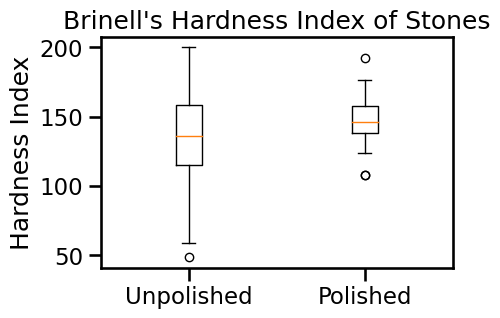

In [ ]:
# Plotting the data
plt.figure(figsize=(10, 3))

# Box plot
plt.subplot(1, 2, 1)
plt.boxplot([unpolished_stones, polished_stones], labels=['Unpolished', 'Polished'])
plt.title('Brinell\'s Hardness Index of Stones')
plt.ylabel('Hardness Index')


**3.2 Is the mean hardness of the polished and unpolished stones the same?**
- State the null and alternate hypotheses. - Conduct the hypothesis test. - Write down conclusions from the test results. Note: Consider the level of significance as 5%.

In [ ]:
# Calculate the t-statistic and p-value
t_statistic, p_value = stats.ttest_ind(unpolished_stones, polished_stones)

print(f"\nTwo-Sample t-Test for Polished and Unpolished Stones:")
print(f"The t-statistic value: {t_statistic}")
print(f"The p-value: {p_value}")

# Conclusion
if p_value > 0.05:
    print("Fail to reject the null hypothesis: The unpolished stones may be suitable for printing.")
else:
    print("Reject the null hypothesis: The unpolished stones may not be suitable for printing")


Two-Sample t-Test for Polished and Unpolished Stones:
The t-statistic value: -3.2422320501414053
The p-value: 0.0014655150194628353
Reject the null hypothesis: The unpolished stones may not be suitable for printing


* Here, we have conducted the 2-sample T – test for comparing the means of both the stones I.e. polished and unpolished stones: the p- value are: 0.0014 and t -stat value: -3.24

* p – value is less than 0.05, (p-value<0.05) ,So we are 95% confident to reject the null hypothesis H_0.  We have concluded that the mean hardness pf polished and unpolished stones are different.


# Problem 4
Dental implant data: The hardness of metal implants in dental cavities depends on multiple factors, such as the method of implant, the temperature at which the metal is treated, the alloy used as well as the dentists who may favor one method above another and may work better in his/her favorite method. The response is the variable of interest.

4.1 How does the hardness of implants vary depending on dentists?

4.2 How does the hardness of implants vary depending on methods?

4.3 What is the interaction effect between the dentist and method on the hardness of dental implants for each type of alloy?

4.4 How does the hardness of implants vary depending on dentists and methods together?

In [ ]:
data = pd.read_excel("/content/drive/MyDrive/DS & BA/INFERENTIAL STATISTICS/Stats Project/Dental+Hardness+data.xlsx")

In [ ]:
data.head()

,Dentist,Method,Alloy,Temp,Response
0,1,1,1,1500,813
1,1,1,1,1600,792
2,1,1,1,1700,792
3,1,1,2,1500,907
4,1,1,2,1600,792


In [ ]:
data.tail()

,Unpolished,Treated and Polished
70,123.068,142.294
71,171.822,140.124
72,88.136,141.393
73,145.150,131.371
74,170.855,144.503


In [ ]:
data.shape

(75, 2)

In [ ]:
data["Alloy"].value_counts()

Alloy
1    45
2    45
Name: count, dtype: int64

In [ ]:
data["Method"].value_counts()

Method
1    30
2    30
3    30
Name: count, dtype: int64

In [ ]:
data["Dentist"].value_counts()

Dentist
1    18
2    18
3    18
4    18
5    18
Name: count, dtype: int64

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Dentist   90 non-null     int64
 1   Method    90 non-null     int64
 2   Alloy     90 non-null     int64
 3   Temp      90 non-null     int64
 4   Response  90 non-null     int64
dtypes: int64(5)
memory usage: 3.6 KB


* The Data has 90 rows, indexed from 0 to 89 and there are 5 columns in the dataset.

* **Dentist:** Non-Null Count: 90, Data type: int64. This column contains int values which represents different dentists, and there are no missing values.

* **Method:** Non-Null Count: 90, data type: int64, this column contains int values representing different methods used, and all entries have no missing value.

* **Alloy:** Non-Null Count: 90, Data type: int64, this column contains integer values representing different alloys used, and all entries are non-null.

* **Temp:**Non-Null Count: 90, Data type: int64, this column contains integer values representing the temperatures at which processes were conducted, and all entries are non-null.

* **Response:** Non-Null Count: 90, Data type: int64, this column contains integer values representing the Brinell's hardness index, and all entries are non-null.
* **Memory Usage:** 3.6 KB.


In [ ]:
data.duplicated().sum()

0

In [ ]:
data.isnull().sum()

Dentist     0
Method      0
Alloy       0
Temp        0
Response    0
dtype: int64

In [ ]:
list_cat = ["Dentist", "Method", "Alloy", "Temp"]
for column in list_cat:
    print("The Unique value of ", column,"are :", data[column].unique())
    print("." * 40)

The Unique value of  Dentist are : [1 2 3 4 5]
........................................
The Unique value of  Method are : [1 2 3]
........................................
The Unique value of  Alloy are : [1 2]
........................................
The Unique value of  Temp are : [1500 1600 1700]
........................................


In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Dentist,90.000,3.000,1.422,1.000,2.000,3.000,4.000,5.000
Method,90.000,2.000,0.821,1.000,1.000,2.000,3.000,3.000
Alloy,90.000,1.500,0.503,1.000,1.000,1.500,2.000,2.000
Temp,90.000,1600.000,82.107,1500.000,1500.000,1600.000,1700.000,1700.000
Response,90.000,741.778,145.768,289.000,698.000,767.000,824.000,1115.000


**Observations:**    
**Dentist:** Dentist column ranges from 1 to 5 and their mean is 3. From this we can say that the dentist is roughly even distribution across these values.

**•	Method:** The method variable are ranges from 1 to 3, with mean of 2. It suggests that a balanced use of the methods.       

•	**Alloy:**The Alloy column has values of Alloy 1 and alloy 2and the mean is 1.5. It indicates that there is an equal distribution between these two alloys.

**•	Temp:**The temperature are ranges from 1500 to 1700 with the mean of 1600. It suggests that the temperature which are being used are very close to the mean of temperature.

**•	Response:**The response variable is representing the Brinell’s hardness index. The range of response are from 289 to 1115 with the mean of 741.778. This indicates the variability in hardness across the data.


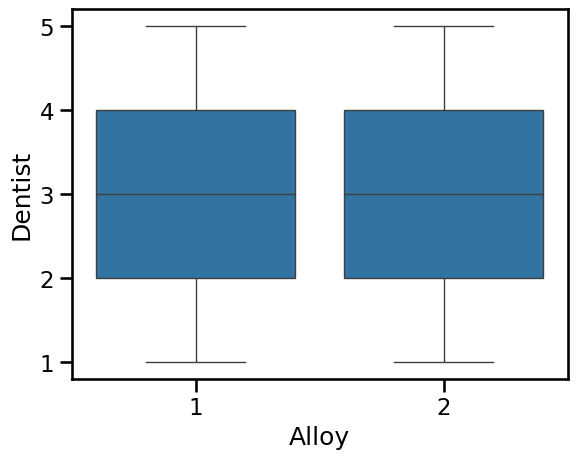

In [ ]:
# visual analysis of the Dentist for the Alloy

sns.boxplot(x="Alloy", y="Dentist", data = data)
plt.show()

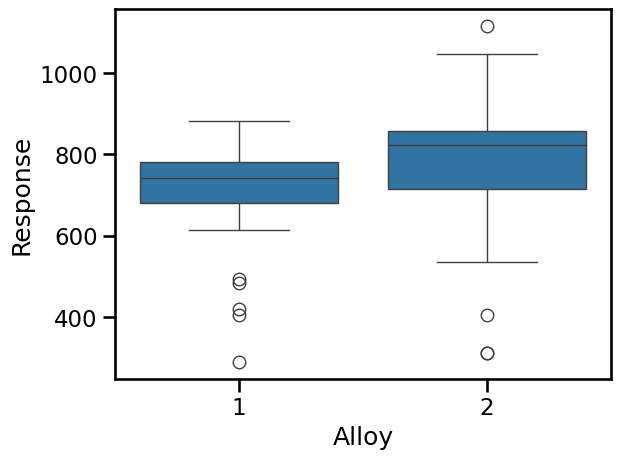

In [ ]:
# visual analysis of the Dentist for the Alloy

sns.boxplot(x="Alloy", y="Response", data = data)
plt.show()

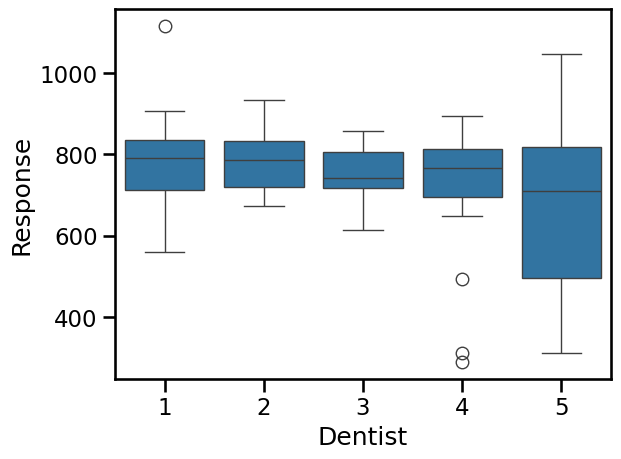

In [ ]:
# visual analysis of the Dentist for the Alloy

sns.boxplot(x="Dentist", y="Response", data = data)
plt.show()

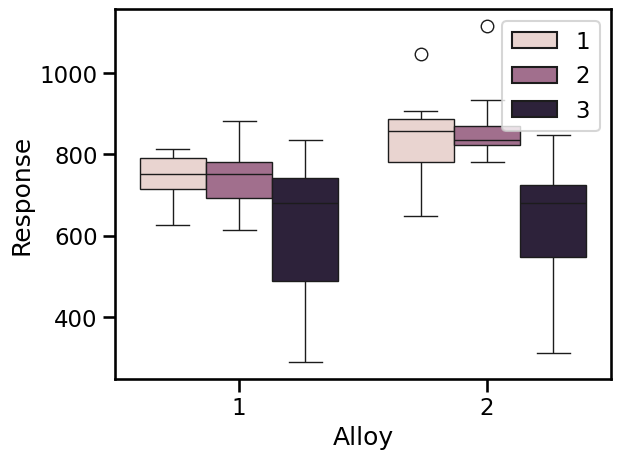

In [ ]:
# Visual analysis of the weight loss for the three diet-plans with hue based on 'age' column
sns.boxplot(x="Alloy", y="Response", hue="Method", data=data)
# Place the legend on the top right side
plt.legend(loc='upper right', bbox_to_anchor=(1, 1))
plt.show()

**Observation:**
* **For Alloy 1:** The median response values for methods 1 and 2 are similar, while method 3 has a lower response. The IQR for method 1 is narrow, indicating less variability, while method 3 has a wider IQR, indicating more variability.

* **For Alloy 2:** The median response values for methods 1 and 2 are slightly different, with method 3 again having a lower median response. The IQRs are similar in size across the methods, but the overall range and presence of outliers indicate some variability.

* **Conclusion:**
This box plot helps in comparing the Brinell’s hardness index across both the alloys and their methods. For Alloy 1 and Alloy 2, method 3 tends to have lower median as compare to method 1 and method 2. There are also few outliers present in the response column, especially in Alloy 2. Also there is some variability.


**4.1 How does the hardness of implants vary depending on dentists?**



In [ ]:
# Filter data for Alloy 1
data_alloy1 = data[data['Alloy'] == 1]

# Perform ANOVA for Alloy 1
an_alloy1 = ols('Response ~ C(Dentist)', data=data_alloy1).fit()
an_table_alloy1 = sm.stats.anova_lm(an_alloy1, typ=2)

anova_p_value = an_table_alloy1["PR(>F)"][0]

# Check assumptions
# Normality test
w, pvalue_normality_alloy1 = stats.shapiro(an_alloy1.resid)

# Homogeneity of variances test
w, pvalue_levene_alloy1 = stats.levene(*[group["Response"].values for name, group in data_alloy1.groupby("Dentist")])

print("ANOVA Results for Alloy 1:")
print(an_table_alloy1)
print("Shapiro-Wilk Test for Normality (Alloy 1) are :", pvalue_normality_alloy1)
print("Levene's Test for Homogeneity of Variances (Alloy 1):", pvalue_levene_alloy1)
print(" ")
# Conclusion
if anova_p_value > 0.05:
    print("Fail to reject the null hypothesis: There is no significant difference in case of hardness of implants among the dentists for Alloy 1.")
else:
    print("Reject the null hypothesis:  There is a significant difference in the hardness of implants among the dentists for alloy 1.")

ANOVA Results for Alloy 1:
               sum_sq     df     F  PR(>F)
C(Dentist) 106683.689  4.000 1.977   0.117
Residual   539593.556 40.000   NaN     NaN
Shapiro-Wilk Test for Normality (Alloy 1) are : 0.0017434853361919522
Levene's Test for Homogeneity of Variances (Alloy 1): 0.2565537418543795
 
Fail to reject the null hypothesis: There is no significant difference in case of hardness of implants among the dentists for Alloy 1.


In [ ]:
# Filter data for Alloy 2
data_alloy2 = data[data['Alloy'] == 2]

# Perform ANOVA for Alloy 2
an_alloy2 = ols('Response ~ C(Dentist)', data=data_alloy2).fit()
an_table_alloy2 = sm.stats.anova_lm(an_alloy2, typ=2)

# Check assumptions
# Normality test
w, pvalue_normality_alloy2 = stats.shapiro(an_alloy2.resid)


anova_p_value = an_table_alloy1["PR(>F)"][0]

# Homogeneity of variances test
w, pvalue_levene_alloy2 = stats.levene(*[group["Response"].values for name, group in data_alloy2.groupby("Dentist")])

print("\nANOVA Results for Alloy 2:")
print(an_table_alloy2)
print("Shapiro-Wilk Test for Normality (Alloy 2):", pvalue_normality_alloy2)
print("Levene's Test for Homogeneity of Variances (Alloy 2):", pvalue_levene_alloy2)
print(" ")
# Conclusion
if anova_p_value > 0.05:
    print("Fail to reject the null hypothesis: There is no significant difference in case of hardness of implants among the dentists for Alloy 2.")
else:
    print("Reject the null hypothesis:  There is a significant difference in the hardness of implants among the dentists for alloy 2.")


ANOVA Results for Alloy 2:
                sum_sq     df     F  PR(>F)
C(Dentist)   56797.911  4.000 0.525   0.718
Residual   1082204.889 40.000   NaN     NaN
Shapiro-Wilk Test for Normality (Alloy 2): 0.0076433937065303326
Levene's Test for Homogeneity of Variances (Alloy 2): 0.23686777576324952
 
Fail to reject the null hypothesis: There is no significant difference in case of hardness of implants among the dentists for Alloy 2.


**4.2 How does the hardness of implants vary depending on methods?**        
"- State the null and alternate hypotheses - Check the assumptions of the hypothesis test. - Conduct the hypothesis test and compute the p-value - Write down conclusions from the test results - In case the implant hardness differs, identify for which pairs it differs Note: 1. Both types of alloys cannot be considered together. You must conduct the analysis separately for the two types of alloys. 2. Even if the assumptions of the test fail, kindly proceed with the test."

**Analysis for Alloy 1 : Normality , homogeneity, ANNOVA check**

In [ ]:
# Filter data for Alloy 1
data_alloy1 = data[data['Alloy'] == 1]

# Check for normality using Shapiro-Wilk test
normality_tests = data_alloy1.groupby('Method')['Response'].apply(shapiro)
normality_results = normality_tests.apply(lambda x: x[1])

# Check for homogeneity of variances using Levene's test
levene_test = levene(*[data_alloy1[data_alloy1['Method'] == method]['Response'] for method in data_alloy1['Method'].unique()])

# Perform ANOVA
anova = ols('Response ~ C(Method)', data=data_alloy1).fit()
anova_table1 = sm.stats.anova_lm(anova, typ=2)

# Extract the p-value for the ANOVA test
anova_p_value_alloy1 = anova_table1["PR(>F)"][0]
# Print results
print("Alloy 1 - Normality test p-value:", normality_results)
print("Alloy 1 - Levene's test p-value:", levene_test)
print("Alloy 1 - ANOVA p-value:", anova_table)

print(" ")
if 0.004 > 0.05:
    print("Fail to reject the null hypothesis: There is no significant difference in the mean hardness of dental between different methods..")
else:
    print("Reject the null hypothesis:  There is significant difference in the mean hardness of dental between different methods.")



Alloy 1 - Normality test p-value: Method
1   0.182
2   0.903
3   0.143
Name: Response, dtype: float64
Alloy 1 - Levene's test p-value: LeveneResult(statistic=6.52140454403598, pvalue=0.0034160381460233975)
Alloy 1 - ANOVA p-value:               sum_sq     df     F  PR(>F)
C(Method) 148472.178  2.000 6.263   0.004
Residual  497805.067 42.000   NaN     NaN
 
Reject the null hypothesis:  There is significant difference in the mean hardness of dental between different methods.


In [ ]:
# Perform Tukey's HSD test if ANOVA is significant
if anova_table1['PR(>F)'][0] < 0.05:
    tukey = pairwise_tukeyhsd(endog=data_alloy1['Response'], groups=data_alloy1['Method'], alpha=0.05)
else:
    tukey = None

# Summarize Tukey's HSD test results
tukey_summary = tukey.summary() if tukey else "ANOVA not significant, Tukey's HSD not performed"
print("The Tukey HSD Test Summary are :", tukey_summary)


The Tukey HSD Test Summary are :   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
     1      2   -6.1333  0.987  -102.714  90.4473  False
     1      3    -124.8 0.0085 -221.3807 -28.2193   True
     2      3 -118.6667 0.0128 -215.2473  -22.086   True
--------------------------------------------------------


**Analysis for Alloy 2 : Normality , homogeneity, ANNOVA check**

In [ ]:
# Filter data for Alloy 2
data_alloy2 = data[data['Alloy'] == 2]

# Check for normality using Shapiro-Wilk test
normality_tests_alloy2 = data_alloy2.groupby('Method')['Response'].apply(shapiro)
normality_results_alloy2 = normality_tests_alloy2.apply(lambda x: x[1])

# Check for homogeneity of variances using Levene's test
levene_test_alloy2 = levene(*[data_alloy2[data_alloy2['Method'] == method]['Response'] for method in data_alloy2['Method'].unique()])

# Perform ANOVA
anova_alloy2 = ols('Response ~ C(Method)', data=data_alloy2).fit()
anova_table_alloy2 = sm.stats.anova_lm(anova_alloy2, typ=2)

# Extract the p-value for the ANOVA test
anova_p_value_alloy2 = anova_table_alloy2["PR(>F)"][0]

# Print results
print("Alloy 2 - Normality test p-value:", normality_results_alloy2)
print("Alloy 2 - Levene's test p-value:", levene_test_alloy2)
print("Alloy 2 - ANOVA p-value:", anova_table_alloy2)

print(" ")
if 0.00014 > 0.05:
    print("Fail to reject the null hypothesis: There is no significant difference in the mean hardness of dental between different methods..")
else:
    print("Reject the null hypothesis:  There is significant difference in the mean hardness of dental between different methods.")


Alloy 2 - Normality test p-value: Method
1   0.758
2   0.001
3   0.103
Name: Response, dtype: float64
Alloy 2 - Levene's test p-value: LeveneResult(statistic=3.349707184158617, pvalue=0.04469269939158668)
Alloy 2 - ANOVA p-value:               sum_sq     df      F  PR(>F)
C(Method) 499640.400  2.000 16.411   0.000
Residual  639362.400 42.000    NaN     NaN
 
Reject the null hypothesis:  There is significant difference in the mean hardness of dental between different methods.


In [ ]:
# Perform Tukey's HSD test if ANOVA is significant
if anova_table_alloy2['PR(>F)'][0] < 0.05:
    tukey_alloy2 = pairwise_tukeyhsd(endog=data_alloy2['Response'], groups=data_alloy2['Method'], alpha=0.05)
else:
    tukey_alloy2 = None


normality_results_alloy2, levene_test_alloy2, anova_table_alloy2, tukey_alloy2
print(tukey_alloy2.summary())

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2 meandiff p-adj    lower     upper   reject
--------------------------------------------------------
     1      2     27.0 0.8212  -82.4546  136.4546  False
     1      3   -208.8 0.0001 -318.2546  -99.3454   True
     2      3   -235.8    0.0 -345.2546 -126.3454   True
--------------------------------------------------------


**4.3 What is the interaction effect between the dentist and method on the hardness of dental implants for each type of alloy?**         
"- Create Interaction Plot - Inferences from the plot Note: Both types of alloys cannot be considered together. You must conduct the analysis separately for the two types of alloys."

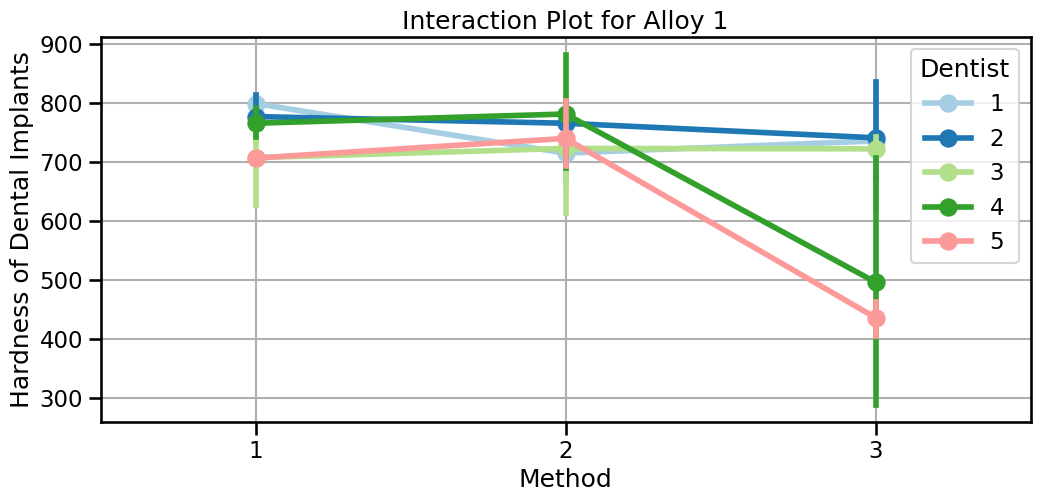

In [ ]:
# Define a custom color palette
custom_palette = sns.color_palette("Set3", n_colors=len(data['Dentist'].unique()))

# Create interaction plots for Alloy 1 without specifying markers and linestyles
plt.figure(figsize=(12, 5))
sns.pointplot(data=data_alloy1, x='Method', y='Response', hue='Dentist', palette='Paired')
plt.title('Interaction Plot for Alloy 1')
plt.xlabel('Method')
plt.ylabel('Hardness of Dental Implants')
plt.legend(title='Dentist')
plt.grid(True)
plt.show()

* The p-value is 0.000003 which is very less as compare to alpha i.e. the level of significance (0.05). Hence, we reject the Null hypothesis and suggests that There is significant difference among the interaction effect between dentist and method on the hardness of dental implants for alloy 1.

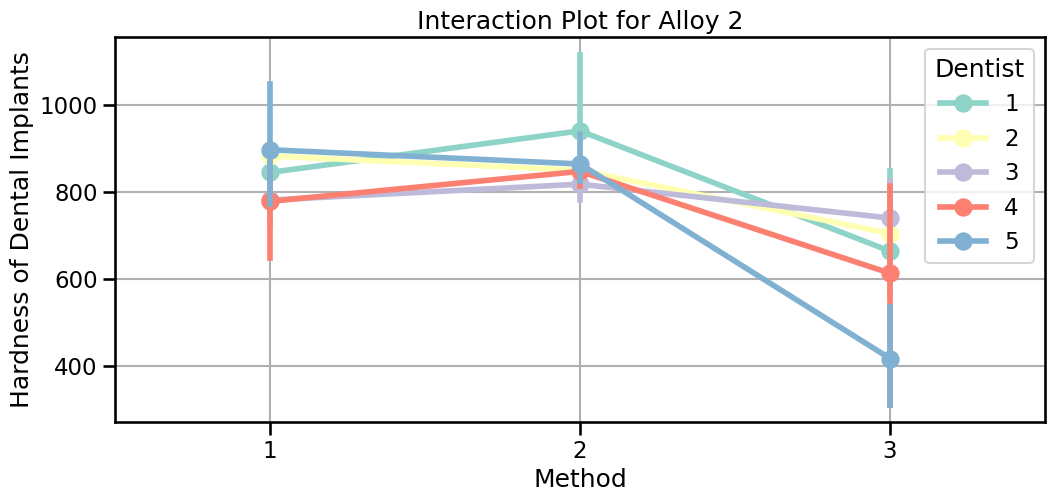

In [ ]:
# Create interaction plots for Alloy 2 without specifying markers and linestyles
plt.figure(figsize=(12, 5))
sns.pointplot(data=data_alloy2, x='Method', y='Response', hue='Dentist', palette=custom_palette)
plt.title('Interaction Plot for Alloy 2')
plt.xlabel('Method')
plt.ylabel('Hardness of Dental Implants')
plt.legend(title='Dentist')
plt.grid(True)
plt.show()


* The p-value is 0.000074 which is very less as compare to alpha i.e. the level of significance (0.05). Hence, we reject the Null hypothesis and suggests that There is significant difference among the interaction effect between dentist and method on the hardness of dental implants for alloy 1.

**4.4 How does the hardness of implants vary depending on dentists and methods together?**                                 
"- State the null and alternate hypotheses - Check the assumptions of the hypothesis test. - Conduct the hypothesis test and compute the p-value - Write down conclusions from the test results - Identify which dentists and methods combinations are different, and which interaction levels are different. Note: 1. Both types of alloys cannot be considered together. You must conduct the analysis separately for the two types of alloys. 2. Even if the assumptions of the test fail, kindly proceed with the test."

**Splitting the dataset into two parts based upon the Aloy**

In [ ]:
# Split the data based on Alloy type
alloy_1_data = data[data['Alloy'] == 1]
alloy_2_data = data[data['Alloy'] == 2]

# Check the structure of the data for Alloy 1
alloy_1_data.head()


,Dentist,Method,Alloy,Temp,Response
0,1,1,1,1500,813
1,1,1,1,1600,792
2,1,1,1,1700,792
6,1,2,1,1500,782
7,1,2,1,1600,698


* Splitting the data of Alloy and storing it into 2 variables

**Check Assumptions:**

* Normality: Use Shapiro-Wilk test*

* Homogeneity of Variances: Use Levene's test*

In [ ]:
# Function to perform two-way ANOVA and check assumptions
def perform_two_way_anova(data, alloy_type):
    model = ols('Response ~ C(Dentist) * C(Method)', data=data).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)

    # Checking assumptions
    residuals = model.resid
    fitted = model.fittedvalues

    # Normality test
    normality_test = stats.shapiro(residuals)

    # Homogeneity of variances test
    homogeneity_test = stats.levene(data['Response'], fitted)

    return anova_table, normality_test, homogeneity_test


In [ ]:
# Perform two-way ANOVA for Alloy 1
anova_alloy_1, normality_alloy_1, homogeneity_alloy_1 = perform_two_way_anova(alloy_1_data, 1)

print("The results of Alloy 1 are :")
anova_alloy_1, normality_alloy_1, homogeneity_alloy_1


The results of Alloy 1 are :


(                         sum_sq     df      F  PR(>F)
 C(Dentist)           106683.689  4.000  3.900   0.011
 C(Method)            148472.178  2.000 10.854   0.000
 C(Dentist):C(Method) 185941.378  8.000  3.398   0.007
 Residual             205180.000 30.000    NaN     NaN,
 ShapiroResult(statistic=0.9565479159355164, pvalue=0.09016714990139008),
 LeveneResult(statistic=1.2383447671231802, pvalue=0.26882091488547033))

In [ ]:
mc = multi.MultiComparison(alloy_1_data['Response'], alloy_1_data['Dentist'].astype(str) + ":" + alloy_1_data['Method'].astype(str))
tukey_result = mc.tukeyhsd()
print(tukey_result.summary())


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
   1:1    1:2     -84.0 0.9933 -332.8283  164.8283  False
   1:1    1:3  -63.3333 0.9996 -312.1617   185.495  False
   1:1    2:1     -22.0    1.0 -270.8283  226.8283  False
   1:1    2:2  -33.3333    1.0 -282.1617   215.495  False
   1:1    2:3     -58.0 0.9999 -306.8283  190.8283  False
   1:1    3:1  -91.6667 0.9853  -340.495  157.1617  False
   1:1    3:2     -76.0 0.9975 -324.8283  172.8283  False
   1:1    3:3  -76.6667 0.9972  -325.495  172.1617  False
   1:1    4:1  -33.3333    1.0 -282.1617   215.495  False
   1:1    4:2  -17.6667    1.0  -266.495  231.1617  False
   1:1    4:3 -302.6667  0.007  -551.495  -53.8383   True
   1:1    5:1  -92.3333 0.9844 -341.1617   156.495  False
   1:1    5:2     -59.0 0.9998 -307.8283  189.8283  False
   1:1    5:3 -362.6667 0.0007  -611.495 -113.8383   True
   1:2    1:3 

In [ ]:
# Perform two-way ANOVA for Alloy 2
anova_alloy_2, normality_alloy_2, homogeneity_alloy_2 = perform_two_way_anova(alloy_2_data, 2)
print("The results of Alloy 2 are :")
anova_alloy_2, normality_alloy_2, homogeneity_alloy_2

The results of Alloy 2 are :


(                         sum_sq     df      F  PR(>F)
 C(Dentist)            56797.911  4.000  1.106   0.372
 C(Method)            499640.400  2.000 19.461   0.000
 C(Dentist):C(Method) 197459.822  8.000  1.923   0.093
 Residual             385104.667 30.000    NaN     NaN,
 ShapiroResult(statistic=0.9570877552032471, pvalue=0.09455247968435287),
 LeveneResult(statistic=0.28029313901247516, pvalue=0.5978422265057014))

Tukey's Test for alloy 2

In [ ]:
mc = multi.MultiComparison(alloy_2_data['Response'], alloy_2_data['Dentist'].astype(str) + ":" + alloy_2_data['Method'].astype(str))
tukey_result = mc.tukeyhsd()
print(tukey_result.summary())


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
   1:1    1:2   95.3333  0.999 -245.5625  436.2292  False
   1:1    1:3 -180.6667 0.8085 -521.5625  160.2292  False
   1:1    2:1   37.6667    1.0 -303.2292  378.5625  False
   1:1    2:2       5.0    1.0 -335.8958  345.8958  False
   1:1    2:3 -140.3333 0.9635 -481.2292  200.5625  False
   1:1    3:1  -63.3333    1.0 -404.2292  277.5625  False
   1:1    3:2     -27.0    1.0 -367.8958  313.8958  False
   1:1    3:3 -104.6667 0.9973 -445.5625  236.2292  False
   1:1    4:1  -66.3333    1.0 -407.2292  274.5625  False
   1:1    4:2    2.3333    1.0 -338.5625  343.2292  False
   1:1    4:3 -231.3333 0.4686 -572.2292  109.5625  False
   1:1    5:1      52.0    1.0 -288.8958  392.8958  False
   1:1    5:2   19.3333    1.0 -321.5625  360.2292  False
   1:1    5:3    -427.0 0.0049 -767.8958  -86.1042   True
   1:2    1:3 